# Notebook 05 — LGD Model, EAD, Expected Loss & IFRS 9

This notebook completes the full **PD / LGD / EAD** credit risk framework and adds:
- IFRS 9 / CECL Stage 1/2/3 classification
- Stress testing sensitivity analysis (conceptually consistent with DFAST/CCAR)

```
Expected Loss = PD × LGD × EAD
```

| Component | Source | Notes |
|---|---|---|
| PD | XGBoost model (NB03) | Probability of early default |
| LGD | Ridge regression (this NB) | 1 − recovery_rate on defaulted loans |
| EAD | Calculation (this NB) | Outstanding principal (`out_prncp`) |

> *This framework is consistent with the expected credit loss (ECL) approach required under IFRS 9 and CECL.*

In [1]:
import sys, pickle, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

from src.preprocessing import NUMERICAL_FEATURES, run_full_pipeline
from src.lgd_ead import (
    prepare_lgd_data,
    train_lgd_model,
    plot_lgd_distribution,
    compute_ead,
    compute_expected_loss,
    plot_expected_loss_breakdown,
    ifrs9_stage_classify,
    ifrs9_summary,
    plot_ifrs9_stages,
    stress_test_portfolio,
    plot_stress_test,
    STRESS_SCENARIOS,
)

plt.rcParams['figure.dpi'] = 120

In [2]:
# Load full dataset and last window artifacts
loan_data = run_full_pipeline('../data/raw/lc_loan.csv')
print(f'Loaded: {loan_data.shape}')

with open('../models/last_window_artifacts.pkl', 'rb') as f:
    art = pickle.load(f)

xgb_best     = art['xgb_best']
preprocessor = art['preprocessor']
X_te_t       = art['X_te_t']
test_window  = art.get('test', None)  # may be None if excluded from pickle

# Get PD predictions for all loans in the last test window
# If test_window is not available, use the stored probs
y_prob_xgb_te = art['y_prob_xgb_te']
y_def_te      = art['y_def_te']

print(f'Test window loans: {len(y_prob_xgb_te):,}')

Loaded: (933159, 64)
Test window loans: 282,138


---
## Part A — LGD Model

**LGD = 1 - recovery_rate**  
**recovery_rate = recoveries / funded_amnt**

Only loans that actually defaulted have recovery data. We train the LGD model on these.

In [3]:
# Prepare LGD dataset (defaulted loans only)
defaulted = prepare_lgd_data(loan_data)

Defaulted loans for LGD training: 49,349
Mean recovery rate:  25.30%
Mean LGD:            74.70%
LGD distribution:
count    49349.0000
mean         0.7470
std          0.1132
min          0.0000
25%          0.6598
50%          0.7410
75%          0.8315
max          1.0000
Name: lgd, dtype: float64


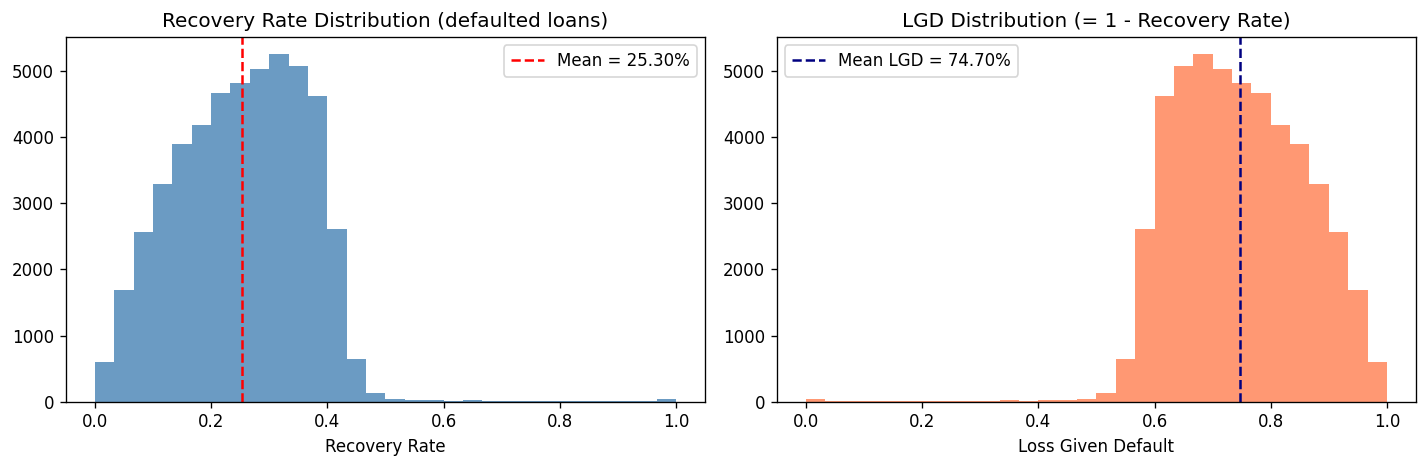

In [4]:
# Visualise LGD distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(defaulted['recovery_rate'], bins=30, color='steelblue', alpha=0.8)
axes[0].set_title('Recovery Rate Distribution (defaulted loans)')
axes[0].set_xlabel('Recovery Rate')
axes[0].axvline(defaulted['recovery_rate'].mean(), color='red', linestyle='--',
                label=f'Mean = {defaulted["recovery_rate"].mean():.2%}')
axes[0].legend()

axes[1].hist(defaulted['lgd'], bins=30, color='coral', alpha=0.8)
axes[1].set_title('LGD Distribution (= 1 - Recovery Rate)')
axes[1].set_xlabel('Loss Given Default')
axes[1].axvline(defaulted['lgd'].mean(), color='navy', linestyle='--',
                label=f'Mean LGD = {defaulted["lgd"].mean():.2%}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Select features for LGD model
# Use numerical features available in both defaulted subset and engineered features
lgd_features = [
    f for f in [
        'log_loan_amnt', 'log_dti', 'fico_avg', 'annual_inc',
        'loan_amnt_to_income_ratio', 'payment_to_income_ratio',
        'grade_interest_interaction', 'fico_int_rate_interaction',
        'int_rate_squared', 'revol_loan_interaction', 'log_revol_bal',
        'installment_fico_interaction',
    ]
    if f in defaulted.columns
]
print(f'LGD model features ({len(lgd_features)}): {lgd_features}')

LGD model features (12): ['log_loan_amnt', 'log_dti', 'fico_avg', 'annual_inc', 'loan_amnt_to_income_ratio', 'payment_to_income_ratio', 'grade_interest_interaction', 'fico_int_rate_interaction', 'int_rate_squared', 'revol_loan_interaction', 'log_revol_bal', 'installment_fico_interaction']


In [6]:
# Train LGD model
lgd_results = train_lgd_model(
    defaulted_df=defaulted,
    feature_cols=lgd_features,
    test_size=0.2,
    random_state=42,
)


LGD Model — Ridge (alpha=10)
  In-sample  R²  : 0.0058
  Out-of-sample R²  : 0.0062
  Out-of-sample MAE : 0.0913

  Interpretation: MAE of 9.13% means the model's
  LGD predictions are off by ~9.13% on average.


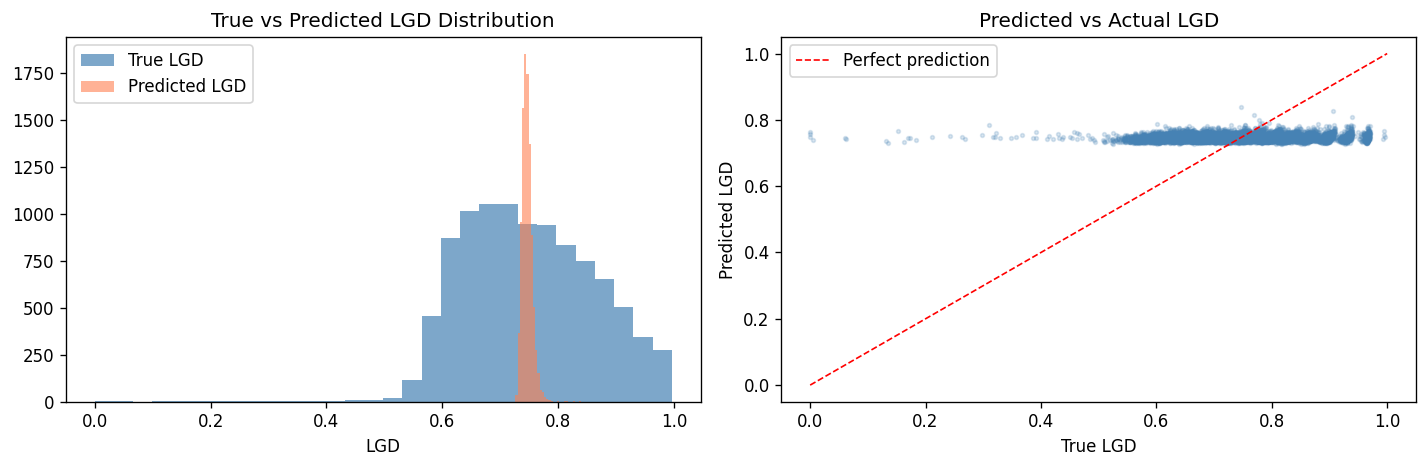

In [7]:
# Visualise true vs predicted LGD
plot_lgd_distribution(lgd_results['y_test'], lgd_results['y_pred'])

In [8]:
# Save LGD model
joblib.dump(lgd_results['model'],  '../models/lgd_model.pkl')
joblib.dump(lgd_results['scaler'], '../models/lgd_scaler.pkl')
print('LGD model saved to ../models/lgd_model.pkl')

LGD model saved to ../models/lgd_model.pkl


---
## Part B — EAD Calculation

**EAD = outstanding principal** (`out_prncp`).  
For performing loans, this is the remaining balance. For already-defaulted loans in the history, it is the exposure at the time of default.  
Credit Conversion Factor (CCF) = 1.0 for term loans (fully drawn).

EAD statistics:
  Mean EAD: $12,555
  Median EAD: $10,000
  Total portfolio EAD: $11,716,002,825


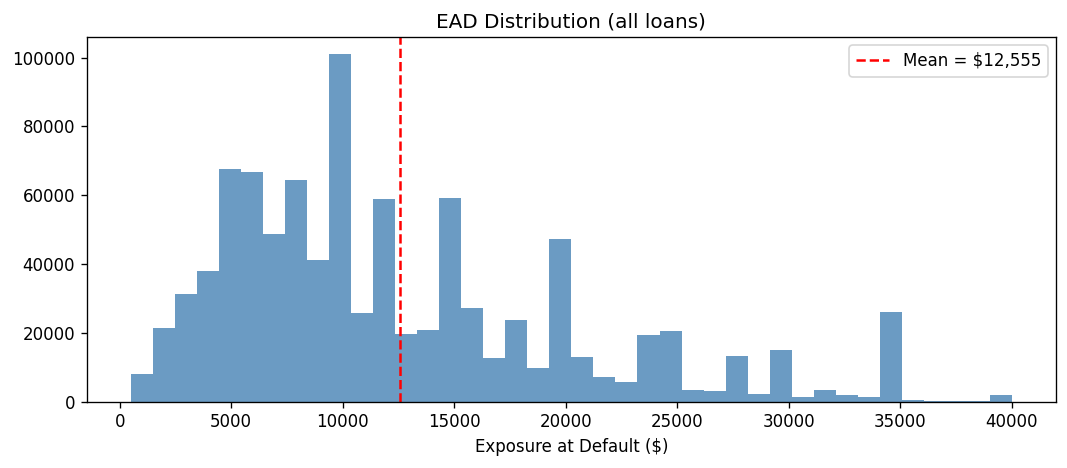

In [9]:
# Compute EAD for all loans
ead_all = compute_ead(loan_data)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ead_all, bins=40, color='steelblue', alpha=0.8)
ax.set_title('EAD Distribution (all loans)')
ax.set_xlabel('Exposure at Default ($)')
ax.axvline(ead_all.mean(), color='red', linestyle='--',
           label=f'Mean = ${ead_all.mean():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part C — Expected Loss = PD × LGD × EAD

We need PD scores, LGD scores, and EAD for the same set of loans.  
We use the last test window from NB03 for PD, and apply the LGD model to the same loans.

In [10]:
# Get the test window subset from the full dataset
# (Reconstruct using the window dates stored in the artifact)
window_start = art['window_start']
from pandas.tseries.offsets import DateOffset
train_end = window_start + DateOffset(months=36)
test_end  = train_end   + DateOffset(months=12)

test_df = loan_data[
    (loan_data['issue_d'] >= train_end) &
    (loan_data['issue_d'] < test_end)
].copy().reset_index(drop=True)

print(f'Test window: {train_end.date()} to {test_end.date()}')
print(f'Test window loans: {len(test_df):,}')

Test window: 2015-01-01 to 2016-01-01
Test window loans: 282,138


In [11]:
# PD scores — from XGBoost (already computed in NB03, reuse)
pd_scores = y_prob_xgb_te  # shape: (n_test,)

# LGD scores — apply the LGD model to test loans
lgd_model  = lgd_results['model']
lgd_scaler = lgd_results['scaler']

# Get LGD features for test loans
lgd_feat_available = [f for f in lgd_features if f in test_df.columns]
X_lgd_test = test_df[lgd_feat_available].fillna(0).values
X_lgd_test_s = lgd_scaler.transform(X_lgd_test)
lgd_scores = np.clip(lgd_model.predict(X_lgd_test_s), 0, 1)

# EAD — from test loans
ead_test = compute_ead(test_df).values

# Align lengths
n = min(len(pd_scores), len(lgd_scores), len(ead_test))
pd_scores  = pd_scores[:n]
lgd_scores = lgd_scores[:n]
ead_test   = ead_test[:n]

print(f'Computing EL for {n:,} loans...')

EAD statistics:
  Mean EAD: $12,803
  Median EAD: $10,000
  Total portfolio EAD: $3,612,321,825
Computing EL for 282,138 loans...


In [12]:
# Compute Expected Loss
el_df = compute_expected_loss(
    pd_scores=pd_scores,
    lgd_scores=lgd_scores,
    ead_values=ead_test,
    loan_ids=test_df['id'].reset_index(drop=True) if 'id' in test_df.columns else None,
)
el_df.head(10)


Portfolio Expected Loss Summary:
  Total EAD:             $  3,612,321,825
  Total Expected Loss:   $    116,347,162
  Portfolio EL Rate:     3.22%
  Mean loan-level PD:    4.29%
  Mean loan-level LGD:   75.15%
  Mean loan-level EAD:   $12,803


,loan_id,pd,lgd,ead,expected_loss,el_rate
0,39679416,0.030390,0.740184,10725.0,241.25,0.022494
1,39629372,0.000737,0.754116,12800.0,7.12,0.000556
2,39599532,0.069174,0.750293,12550.0,651.35,0.051901
3,39519409,0.007535,0.746539,10000.0,56.25,0.005625
4,39639365,0.054182,0.754307,3000.0,122.61,0.040870
5,39589409,0.001531,0.746413,9550.0,10.92,0.001143
6,39409461,0.017193,0.761971,6000.0,78.60,0.013101
7,39519203,0.064934,0.738309,16000.0,767.06,0.047942
8,39529336,0.011502,0.760329,15000.0,131.18,0.008745
9,39340590,0.048324,0.752343,10400.0,378.10,0.036356


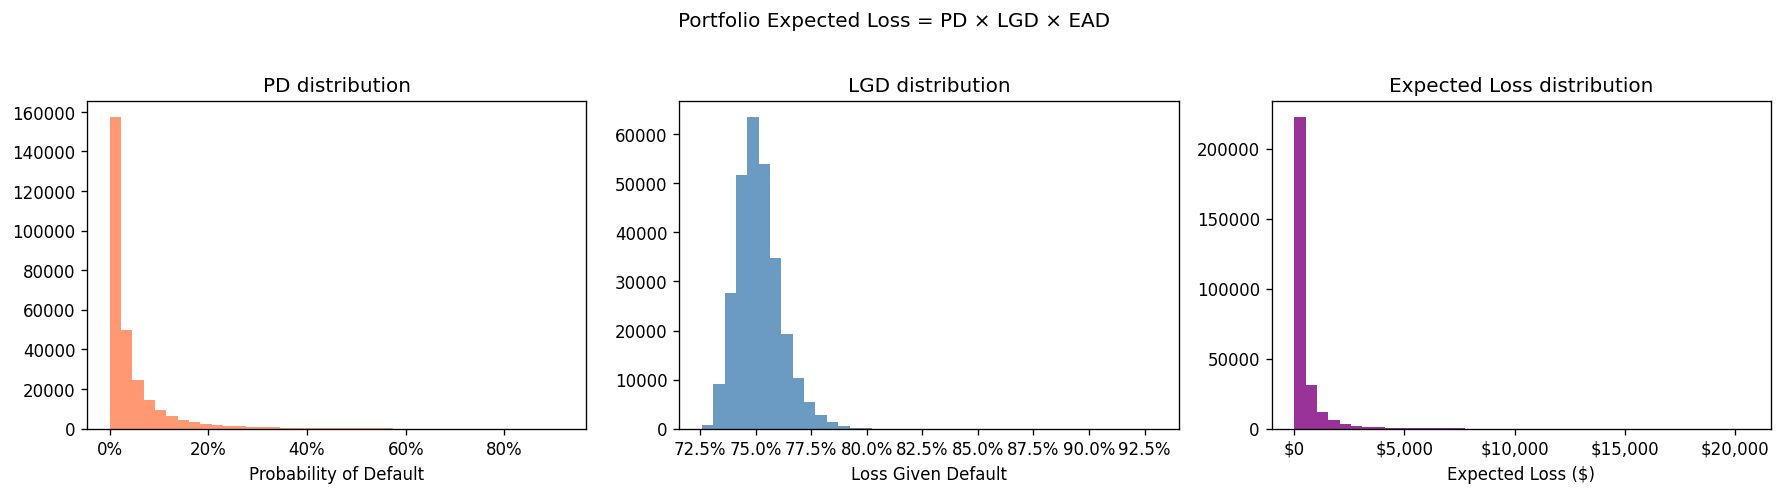

In [13]:
plot_expected_loss_breakdown(el_df)

---
## Part D — IFRS 9 / CECL Stage Classification

IFRS 9 requires banks to classify loans into stages based on credit risk deterioration since origination:

| Stage | ECL horizon | PD threshold (illustrative) |
|---|---|---|
| Stage 1 | 12-month ECL | PD < 10% |
| Stage 2 | Lifetime ECL | 10% ≤ PD < 30% |
| Stage 3 | Lifetime ECL (credit-impaired) | PD ≥ 30% |

In [14]:
stage_summary = ifrs9_summary(
    pd_scores=pd_scores,
    el_df=el_df,
    stage2_threshold=0.10,
    stage3_threshold=0.30,
)


IFRS 9 / CECL Stage Classification Summary
Stage 1 (12-month ECL):   PD < 10%
Stage 2 (Lifetime ECL):   10% ≤ PD < 30%
Stage 3 (Credit-impaired): PD ≥ 30%

       loan_count     total_ead     total_el  mean_pd  mean_lgd  ead_pct  el_rate
stage                                                                            
1          250510  3.208314e+09  57039543.84   0.0237    0.7515    88.82   1.7779
2           27428  3.499646e+08  42378913.12   0.1615    0.7514     9.69  12.1095
3            4200  5.404320e+07  16928705.27   0.4159    0.7516     1.50  31.3244

Note: In practice, Stage migration is triggered by PD deterioration
vs origination PD, not absolute PD thresholds alone.


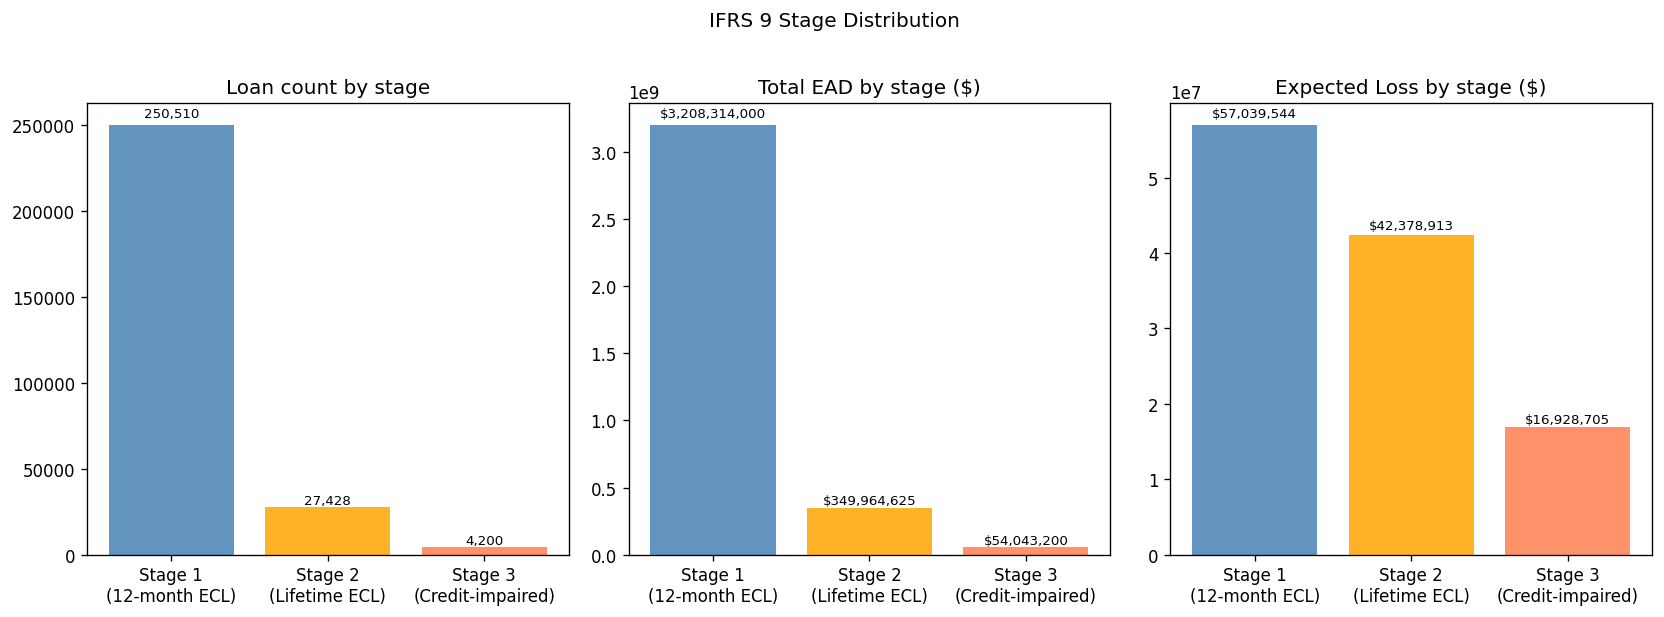

In [15]:
plot_ifrs9_stages(el_df, pd_scores,
                  stage2_threshold=0.10, stage3_threshold=0.30)

In [16]:
# Add stage to EL DataFrame
el_df['ifrs9_stage'] = ifrs9_stage_classify(pd_scores)

# EL rate by stage
stage_el = el_df.groupby('ifrs9_stage').agg(
    loans=('pd', 'count'),
    total_ead=('ead', 'sum'),
    total_el=('expected_loss', 'sum'),
    mean_pd=('pd', 'mean'),
).assign(el_rate=lambda x: x['total_el'] / x['total_ead'])

print('IFRS 9 ECL by Stage:')
display(stage_el.round(4))

IFRS 9 ECL by Stage:


,loans,total_ead,total_el,mean_pd,el_rate
ifrs9_stage,,,,,
1,250510,3.208314e+09,57039543.84,0.0237,0.0178
2,27428,3.499646e+08,42378913.12,0.1615,0.1211
3,4200,5.404320e+07,16928705.27,0.4159,0.3132


---
## Part E — Stress Testing

Stress scenarios apply PD and LGD multipliers to simulate adverse macro conditions:
- **PD multiplier:** simulates a recession increasing default frequency
- **LGD multiplier:** simulates collateral value decline reducing recoveries

> *Illustrative sensitivity analysis — not DFAST/CCAR-compliant macro modelling.*

In [17]:
stress_results = stress_test_portfolio(
    pd_scores=pd_scores,
    lgd_scores=lgd_scores,
    ead_values=ead_test,
    scenarios=STRESS_SCENARIOS,
)


Portfolio Stress Test Results
        Scenario PD multiplier LGD multiplier Portfolio EAD ($) Expected Loss ($) EL Rate            EL vs Base
  Base (current)         1.00×          1.00×    $3,612,321,825      $116,347,162   3.22%                  Base
     Mild stress         1.25×          1.05×    $3,612,321,825      $152,691,418   4.23%   +36,344,256 (31.2%)
 Moderate stress         1.50×          1.10×    $3,612,321,825      $191,781,439   5.31%   +75,434,277 (64.8%)
   Severe stress         2.00×          1.20×    $3,612,321,825      $277,331,177   7.68% +160,984,014 (138.4%)
Extreme (crisis)         3.00×          1.30×    $3,612,321,825      $439,584,256  12.17% +323,237,094 (277.8%)

Note: PD multipliers simulate macroeconomic stress (e.g., 2.0× PD = severe recession).
LGD multipliers simulate collateral value decline and reduced recovery in downturns.
This is illustrative stress sensitivity — not a DFAST/CCAR-compliant macro model.


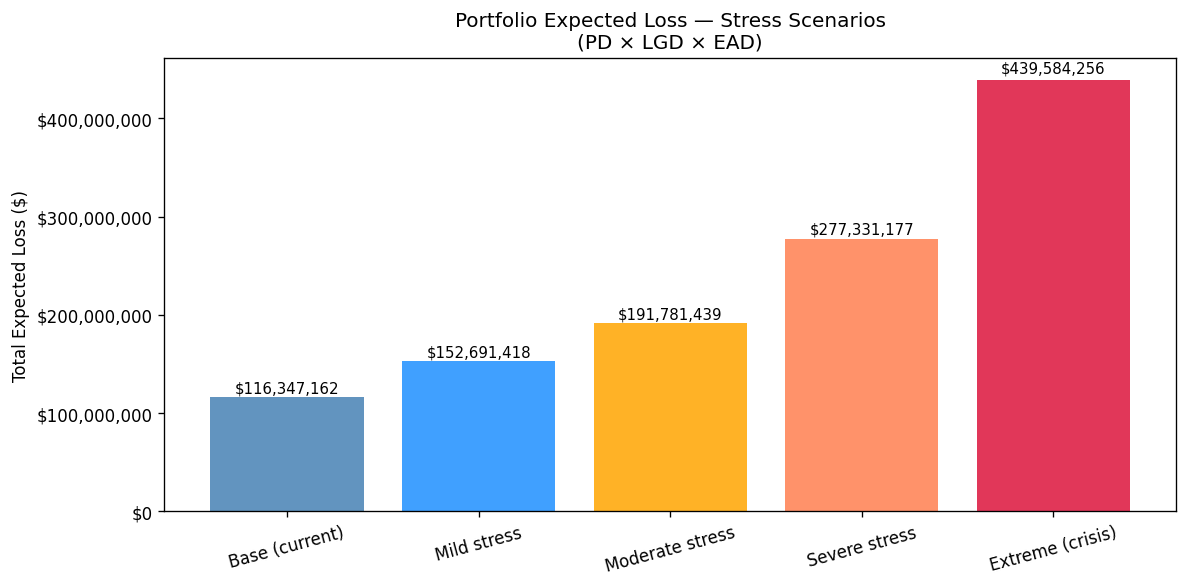

In [18]:
plot_stress_test(pd_scores, lgd_scores, ead_test)

In [19]:
display(stress_results)

,Scenario,PD multiplier,LGD multiplier,Portfolio EAD ($),Expected Loss ($),EL Rate,EL vs Base
0,Base (current),1.00×,1.00×,"$3,612,321,825","$116,347,162",3.22%,Base
1,Mild stress,1.25×,1.05×,"$3,612,321,825","$152,691,418",4.23%,"+36,344,256 (31.2%)"
2,Moderate stress,1.50×,1.10×,"$3,612,321,825","$191,781,439",5.31%,"+75,434,277 (64.8%)"
3,Severe stress,2.00×,1.20×,"$3,612,321,825","$277,331,177",7.68%,"+160,984,014 (138.4%)"
4,Extreme (crisis),3.00×,1.30×,"$3,612,321,825","$439,584,256",12.17%,"+323,237,094 (277.8%)"


---
## Part F — Complete Framework Summary

In [20]:
from sklearn.metrics import roc_auc_score

print('Complete Credit Risk Framework Summary')
print('=' * 60)
print()
print('PD Model (XGBoost):')
print(f'  ROC-AUC (out-of-sample):  {roc_auc_score(y_def_te[:n], pd_scores):.4f}')
print(f'  Mean predicted PD:        {pd_scores.mean():.2%}')
print()
print('LGD Model (Ridge):')
print(f'  R² (out-of-sample):       {lgd_results["r2_out"]:.4f}')
print(f'  MAE (out-of-sample):      {lgd_results["mae_out"]:.4f}')
print(f'  Mean predicted LGD:       {lgd_scores.mean():.2%}')
print()
print('EAD:')
print(f'  Mean EAD:                 ${ead_test.mean():,.0f}')
print(f'  Total portfolio EAD:      ${ead_test.sum():,.0f}')
print()
print('Expected Loss (PD × LGD × EAD):')
print(f'  Total Expected Loss:      ${el_df["expected_loss"].sum():,.0f}')
print(f'  Portfolio EL Rate:        {el_df["expected_loss"].sum() / el_df["ead"].sum():.2%}')
print()
print('IFRS 9 Stage Distribution:')
stage_counts = el_df['ifrs9_stage'].value_counts().sort_index()
for stage, count in stage_counts.items():
    pct = count / len(el_df) * 100
    print(f'  Stage {stage}: {count:,} loans ({pct:.1f}%)')
print()
print('Stress Test (EL at moderate stress, 1.5× PD / 1.1× LGD):')
print('  → See table above')
print()
print('Framework alignment:')
print('  ✓ PD  — XGBoost classifier')
print('  ✓ LGD — Ridge regression on recovery rate')
print('  ✓ EAD — Outstanding principal calculation')
print('  ✓ EL  — PD × LGD × EAD at loan and portfolio level')
print('  ✓ CECL/IFRS 9 — Stage 1/2/3 classification')
print('  ✓ Stress testing — 5-scenario sensitivity analysis')

Complete Credit Risk Framework Summary

PD Model (XGBoost):
  ROC-AUC (out-of-sample):  0.6320
  Mean predicted PD:        4.29%

LGD Model (Ridge):
  R² (out-of-sample):       0.0062
  MAE (out-of-sample):      0.0913
  Mean predicted LGD:       75.15%

EAD:
  Mean EAD:                 $12,803
  Total portfolio EAD:      $3,612,321,825

Expected Loss (PD × LGD × EAD):
  Total Expected Loss:      $116,347,162
  Portfolio EL Rate:        3.22%

IFRS 9 Stage Distribution:
  Stage 1: 250,510 loans (88.8%)
  Stage 2: 27,428 loans (9.7%)
  Stage 3: 4,200 loans (1.5%)

Stress Test (EL at moderate stress, 1.5× PD / 1.1× LGD):
  → See table above

Framework alignment:
  ✓ PD  — XGBoost classifier
  ✓ LGD — Ridge regression on recovery rate
  ✓ EAD — Outstanding principal calculation
  ✓ EL  — PD × LGD × EAD at loan and portfolio level
  ✓ CECL/IFRS 9 — Stage 1/2/3 classification
  ✓ Stress testing — 5-scenario sensitivity analysis


In [21]:
# Save EL results
os.makedirs('../data/outputs', exist_ok=True)
el_df.to_csv('../data/outputs/expected_loss_results.csv', index=False)
stress_results.to_csv('../data/outputs/stress_test_results.csv', index=False)
stage_summary.to_csv('../data/outputs/ifrs9_stage_summary.csv')
print('Results saved to ../data/outputs/')

Results saved to ../data/outputs/
